# The Numbers Never Lie? Galton, Eugenics, and the Birth of Statistics

**Module 1 of 3** | Critical Thinking with Data

Author: [Parshv Patel](https://www.linkedin.com/in/parshv-patel-65a90326b/)

**Estimated time:** 2-3 class periods (approx. 150-200 minutes total)

---

## Learning Objectives

By the end of this module, you will be able to:

1. Explain the historical origins of statistical tools like correlation and regression, and connect them to the eugenics movement.
2. Load a real dataset and produce basic descriptive statistics (mean, median, standard deviation).
3. Identify sampling bias in a dataset and explain what populations are over- or under-represented.
4. Interpret a correlation coefficient and distinguish correlation from causation.
5. Read a scatter plot with a regression line and explain what the slope tells you.
6. Define "regression to the mean" in plain language and explain why it mattered historically.
7. Evaluate how the purpose of a study shapes the data collected and the conclusions drawn.
8. Describe Galton's "transmutation" of female heights and explain why it is methodologically and ethically problematic.
9. Ask three critical questions about any dataset: Who collected it? Why? Who was left out?

In [1]:
# Environment bootstrap for Colab/local use
# Fetches required data/image assets into expected paths.

import os
import sys
import subprocess
from pathlib import Path
from urllib.request import urlretrieve

base_raw = "https://raw.githubusercontent.com/ariavasulin/critical-thinking-with-data/main/assets/notebooks/module-1"
required_files = {
    "data/Galton_Family_Heights.csv": f"{base_raw}/data/Galton_Family_Heights.csv",
    "figures/Francis_Galton2.jpg": f"{base_raw}/figures/Francis_Galton2.jpg",
    "figures/Francis_Galton_1850s.jpg": f"{base_raw}/figures/Francis_Galton_1850s.jpg",
    "figures/Sir_Francis_Galton,_1890s.jpg": f"{base_raw}/figures/Sir_Francis_Galton,_1890s.jpg",
    "figures/child_height_distributions.png": f"{base_raw}/figures/child_height_distributions.png",
    "figures/correlation_heatmap.png": f"{base_raw}/figures/correlation_heatmap.png",
    "figures/correlation_heatmap_nb.png": f"{base_raw}/figures/correlation_heatmap_nb.png",
    "figures/eda_combined_display.png": f"{base_raw}/figures/eda_combined_display.png",
    "figures/height_boxplots.png": f"{base_raw}/figures/height_boxplots.png",
    "figures/module1_summary_display.png": f"{base_raw}/figures/module1_summary_display.png",
    "figures/module1_summary_figure.png": f"{base_raw}/figures/module1_summary_figure.png",
    "figures/regression_to_mean.png": f"{base_raw}/figures/regression_to_mean.png",
    "figures/regression_to_mean_nb.png": f"{base_raw}/figures/regression_to_mean_nb.png",
    "figures/residual_analysis.png": f"{base_raw}/figures/residual_analysis.png",
    "figures/residual_analysis_nb.png": f"{base_raw}/figures/residual_analysis_nb.png",
    "figures/scatter_regression_plots.png": f"{base_raw}/figures/scatter_regression_plots.png",
    "figures/scatter_regression_plots_nb.png": f"{base_raw}/figures/scatter_regression_plots_nb.png",
    "figures/transmutation_comparison.png": f"{base_raw}/figures/transmutation_comparison.png",
    "figures/transmutation_comparison_nb.png": f"{base_raw}/figures/transmutation_comparison_nb.png",
}

Path("data").mkdir(exist_ok=True)
Path("images").mkdir(exist_ok=True)
Path("figures").mkdir(exist_ok=True)

for local_path, remote_url in required_files.items():
    path = Path(local_path)
    if not path.exists():
        urlretrieve(remote_url, local_path)

missing = [p for p in required_files if not Path(p).exists()]
if missing:
    raise FileNotFoundError(f"Missing required notebook assets: {missing}")

print("Bootstrap complete: module assets are ready.")

Bootstrap complete: module assets are ready.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
import json
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
sns.set_style('whitegrid')

print('Setup complete.')

Setup complete.


In [3]:
# Load the dataset
df = pd.read_csv('data/Galton_Family_Heights.csv')

# Load pre-computed stats
with open('data/galton_stats.json') as f:
    stats_dict = json.load(f)

print(f'Dataset shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
print()
df.head(5)

Dataset shape: (934, 4)
Columns: ['Father_height', 'Mother_height', 'Child_height', 'gender']



,Father_height,Mother_height,Child_height,gender
0,78.5,67.0,73.2,1
1,78.5,67.0,69.2,0
2,78.5,67.0,69.0,0
3,78.5,67.0,69.0,0
4,75.5,66.5,73.5,1


### A Note on the Columns

| Column | What it means |
|---|---|
| `Father_height` | Father's height in inches |
| `Mother_height` | Mother's height in inches |
| `Child_height` | Adult child's height in inches |
| `gender` | Child's gender: **1 = Male**, **0 = Female** |

All heights are in **inches**. The `gender` column uses numeric codes. We will always use `gender == 1` for males and `gender == 0` for females in our code. You will not see string labels like `'M'` or `'F'` here.

---
## Part 1: Historical Context

### London, 1884

Picture this: the International Health Exhibition has come to South Kensington, London. Thousands of visitors stream through exhibits on food, sanitation, and the science of the body. Tucked inside is a small booth run by a 62-year-old polymath named Francis Galton. For three pennies apiece, visitors can be precisely measured, height, weight, arm span, eyesight, strength. Galton called it his Anthropometric Laboratory.

Who paid those three pennies? The working poor, struggling to survive in Victorian London, were almost certainly not among them. The visitors were overwhelmingly middle- and upper-class white English families, people with leisure time, disposable income, and enough confidence in their own bodies to offer them up for scientific measurement. Galton collected data on roughly 9,000 people over the course of the exhibition, and the families whose heights we are about to analyze came from that same pool.

Francis Galton was no ordinary hobbyist. He was a half-cousin of Charles Darwin, a Fellow of the Royal Society, and a man consumed by a single question: can human intelligence, character, and physical ability be inherited, and if so, can society be engineered to produce more of the "best" people? In 1883, just one year before this exhibition, he coined the word **eugenics**, from the Greek *eu* (good) and *genos* (in stock, or birth). His goal was the scientific justification for controlling who reproduced.

Height was central to this project. In Galton's worldview, tall stature was a visible marker of hereditary "worth." If he could show that height passed reliably from parent to child, and that certain families consistently produced taller, "superior" offspring, he would have a quantitative foundation for arguing that selective breeding could improve the human race. This was not a fringe view in Victorian Britain. Galton was celebrated, knighted, and widely read. The tools he invented to pursue these ideas: correlation, regression, the standard deviation, became the foundations of modern statistics.

Those tools are genuinely powerful. We still use them today in medicine, economics, social science, and machine learning. That is exactly the tension this module asks you to sit with.

**So why are we still using this dataset to teach statistics today?**

Because the data is real, the math works, and as you will discover, the results actually undermined Galton's own argument in ways he never fully acknowledged. But that story only makes sense if you know where the data came from.

*Sources: [Galton's Anthropometric Laboratory (Nautilus)](https://nautil.us/how-eugenics-shaped-statistics-238014/), [Francis Galton: Wikipedia](https://en.wikipedia.org/wiki/Francis_Galton), [Gorroochurn 2016 On Galton’s Change From 'Reversion' to 'Regression' (tandfonline)](https://www.tandfonline.com/doi/full/10.1080/00031305.2015.1087876#d1e100)*

---
### Stop and Think
*Take 3 minutes on your own before discussing with anyone.*

**Question 1:** If you were designing a study of height inheritance today, who would you include? Who might you leave out, accidentally or on purpose? What would make your sample more representative?

**Question 2:** A dataset can be biased in how it was collected and still produce useful mathematical results. Do you think that is possible? How would you know if a dataset's biases were affecting your conclusions?

---

### About This Dataset

The dataset we are working with contains **934 rows** representing individual adult children from **205 families** who participated in Galton's study. Each row records the father's height, the mother's height, the adult child's height, and the child's gender.

The original data was digitized and made available through the [Harvard Dataverse](https://dataverse.harvard.edu/) and is widely circulated via Kaggle. It is one of the most-used teaching datasets in introductory statistics courses worldwide, usually without the history you just read.

In [4]:
# Quick data inspection
print('--- Shape ---')
print(df.shape)

print('\n--- Data types ---')
print(df.dtypes)

print('\n--- Missing values ---')
print(df.isnull().sum())

print('\n--- First 5 rows ---')
df.head()

--- Shape ---
(934, 4)

--- Data types ---
Father_height    float64
Mother_height    float64
Child_height     float64
gender             int64
dtype: object

--- Missing values ---
Father_height    0
Mother_height    0
Child_height     0
gender           0
dtype: int64

--- First 5 rows ---


,Father_height,Mother_height,Child_height,gender
0,78.5,67.0,73.2,1
1,78.5,67.0,69.2,0
2,78.5,67.0,69.0,0
3,78.5,67.0,69.0,0
4,75.5,66.5,73.5,1


---
## Part 2: Getting to Know the Data: Exploratory Data Analysis

### Step 1: Look at the Data

Before running any models or drawing any conclusions, a good data analyst spends time simply *looking* at the data. This process is called **Exploratory Data Analysis (EDA)**. The goal is to understand what you have: how spread out is it? Are there any obvious patterns? Any surprising values? Any groups that behave differently from others?

The habits you build in EDA are what separate careful analysis from careless analysis, and they are exactly the habits that Galton himself skipped when it suited him.

In [5]:
# Descriptive statistics for all numeric columns
df.describe().round(2)

,Father_height,Mother_height,Child_height,gender
count,934.00,934.00,934.00,934.00
mean,69.20,64.09,66.75,0.51
std,2.48,2.29,3.58,0.50
min,62.00,58.00,56.00,0.00
25%,68.00,63.00,64.00,0.00
50%,69.00,64.00,66.50,1.00
75%,71.00,65.88,69.70,1.00
max,78.50,70.50,79.00,1.00


### Key Terms

| Term | Plain-language definition |
|---|---|
| **Dataset** | A structured collection of information, organized into rows (observations) and columns (variables) |
| **Observation** | One row, in this case, one adult child |
| **Variable** | One column, a characteristic measured for each observation |
| **Mean** | The arithmetic average, add all values, divide by how many there are |
| **Median** | The middle value when sorted, half the data is above it, half below |
| **Standard deviation** | A measure of spread, roughly, the average distance of each value from the mean |
| **Distribution** | The overall pattern of how values are spread across a range |

---

Notice in the table above: `Father_height` ranges from 62" to 78.5", with a mean of approximately 69.2". That range is quite narrow. Modern data shows that adult male heights in the US range from roughly 59" to 80", with meaningful variation by ancestry and socioeconomic background. The narrow range here is a clue that this was not a random sample of the population. It was a convenience sample of people who showed up at a paid exhibition.

In [6]:
# Gender breakdown
gender_counts = df['gender'].value_counts().sort_index(ascending=False)
print('Gender value counts (1=Male, 0=Female):')
print(gender_counts)
print()

n_male   = stats_dict['gender_stats']['n_male']
n_female = stats_dict['gender_stats']['n_female']
pct_male   = stats_dict['gender_stats']['pct_male']
pct_female = stats_dict['gender_stats']['pct_female']

print(f'Male   (gender=1): {n_male} children ({pct_male}% of sample)')
print(f'Female (gender=0): {n_female} children ({pct_female}% of sample)')
print(f'Total:             {n_male + n_female} children')

Gender value counts (1=Male, 0=Female):
gender
1    481
0    453
Name: count, dtype: int64

Male   (gender=1): 481 children (51.5% of sample)
Female (gender=0): 453 children (48.5% of sample)
Total:             934 children


In [7]:
# Child height statistics grouped by gender
gender_height_stats = (
    df.groupby('gender')['Child_height']
      .agg(['mean', 'median', 'std'])
      .round(2)
      .rename(index={1: 'Male (gender=1)', 0: 'Female (gender=0)'})
)
print('Child height by gender:')
print(gender_height_stats)
print()

male_mean   = stats_dict['gender_stats']['mean_child_male']
female_mean = stats_dict['gender_stats']['mean_child_female']
print(f'Male child mean height:   {male_mean}"')
print(f'Female child mean height: {female_mean}"')
print(f'Difference:               {male_mean - female_mean:.3f}"')
print()
print('Interpretation: Male children in this dataset are on average ~5.1" taller than female children.')
print('This difference will matter a great deal in Part 4 when we examine Galton\'s transmutation technique.')

Child height by gender:
                    mean  median   std
gender                                
Female (gender=0)  64.10    64.0  2.36
Male (gender=1)    69.23    69.2  2.62

Male child mean height:   69.234"
Female child mean height: 64.104"
Difference:               5.130"

Interpretation: Male children in this dataset are on average ~5.1" taller than female children.
This difference will matter a great deal in Part 4 when we examine Galton's transmutation technique.


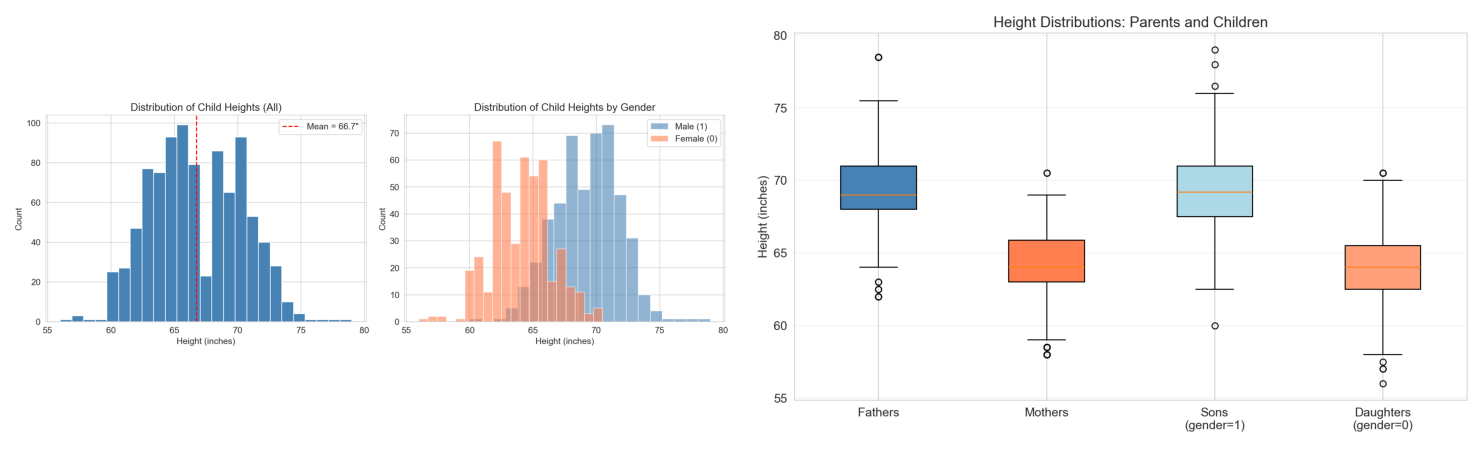

Left: Histograms of child heights. Overall and split by gender.
Right: Box plots comparing parent and child height distributions.

Notice in the histogram: male and female heights form two distinct peaks (bimodal distribution).
This separation is a key feature Galton had to deal with, and the way he dealt with it is the subject of Part 4.


In [8]:
# Display pre-generated distribution figures
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

img1 = mpimg.imread('figures/child_height_distributions.png')
img2 = mpimg.imread('figures/height_boxplots.png')

axes[0].imshow(img1)
axes[0].axis('off')
axes[1].imshow(img2)
axes[1].axis('off')

plt.tight_layout()
plt.savefig('figures/eda_combined_display.png', dpi=120, bbox_inches='tight')
plt.show()

print('Left: Histograms of child heights. Overall and split by gender.')
print('Right: Box plots comparing parent and child height distributions.')
print()
print('Notice in the histogram: male and female heights form two distinct peaks (bimodal distribution).')
print('This separation is a key feature Galton had to deal with, and the way he dealt with it is the subject of Part 4.')

---
### Pair Discussion
*With a partner, discuss for 5 minutes.*

1. Look at the father height range (62" to 78.5"). The average American adult male today is about 5'9" (69"). Does the range in this dataset seem narrow to you? What kinds of people might be missing?

2. This dataset contains only people from 205 families who paid to be measured at a Victorian exhibition in London in 1884. Can we generalize conclusions from this dataset to: (a) all British people in 1884? (b) all people globally today? Why or why not?

3. The dataset has 934 children from 205 families, that means some families contributed multiple children. Does that change how you think about each row as an independent "observation"?

4. There is no information about race, ethnicity, income, or nationality in this dataset. Is that absence neutral? Or does it tell us something?

---

---
## Part 3: What Galton Found: Correlation and Regression

### The Discovery

When Galton plotted parent heights against child heights, he found what he expected: tall parents tended to have taller children, and short parents tended to have shorter children. This confirmed that height had a heritable component. So far, so good for Galton's theory.

But then something unexpected emerged. The relationship was not one-to-one. If a father was 4 inches taller than average, his sons were typically only about 1.8 inches taller than average, not 4 inches. Children of very tall parents were tall, yes, but not *as* tall as their parents. Children of very short parents were short, but not *as* short. Every generation, heights drifted back toward the overall average.

Galton called this **"regression toward mediocrity."** He did not mean that children were mediocre people. He meant that extreme values, statistical outliers, tend, over generations, to pull back toward the center of the distribution.

This observation gave us the word **regression** as we use it in data science today. When you fit a regression line in Python or R or Excel, you are using a technique named after this very finding, tall parents regressing, in their children's heights, back to the mean.

The irony, as we will see, is that this finding quietly demolished Galton's eugenic hopes. If traits always drift back toward the average, selective breeding has limits. The mathematical tool he invented to support eugenics ended up arguing against it.

*Source: [Gorroochurn (2016), "On Galton’s Change From 'Reversion' to 'Regression'", Columbia University / Taylor & Francis](https://www.tandfonline.com/doi/full/10.1080/00031305.2015.1087876#d1e100)*

### What Is Correlation?

Correlation measures how strongly two numeric variables move together. The result, called **Pearson's r**, always falls between -1 and +1:

- **r = +1**: Perfect positive relationship , as one goes up, the other always goes up proportionally
- **r = 0**: No linear relationship , knowing one tells you nothing about the other
- **r = -1**: Perfect negative relationship , as one goes up, the other always goes down

A common analogy: imagine a cloud of dots on a scatter plot. A tight, upward-sloping cloud means high positive correlation. A loose, shapeless blob means low correlation. **Correlation tells you about the shape of the cloud. It does not tell you what caused that shape.**

> **Critical reminder:** Correlation is NOT causation. Two variables can correlate because one causes the other, because both are caused by a third variable (confunding factor), or purely by chance. Galton understood this in principle, but his interpretations often slipped from correlation to causal inference anyway.

In [9]:
# Compute mid-parent height (average of father and mother)
df['mid_parent'] = (df['Father_height'] + df['Mother_height']) / 2

# Separate by gender
males   = df[df['gender'] == 1]
females = df[df['gender'] == 0]

# Compute all 7 correlations
corr_father_all       = df['Father_height'].corr(df['Child_height'])
corr_mother_all       = df['Mother_height'].corr(df['Child_height'])
corr_father_sons      = males['Father_height'].corr(males['Child_height'])
corr_father_daughters = females['Father_height'].corr(females['Child_height'])
corr_mother_sons      = males['Mother_height'].corr(males['Child_height'])
corr_mother_daughters = females['Mother_height'].corr(females['Child_height'])
corr_midparent        = df['mid_parent'].corr(df['Child_height'])

print('Parent-Child Correlations (Pearson r)')
print('=' * 45)
print(f'Father ~ Child (all children):    r = {corr_father_all:.3f}')
print(f'Mother ~ Child (all children):    r = {corr_mother_all:.3f}')
print(f'Father ~ Child (sons only):       r = {corr_father_sons:.3f}')
print(f'Father ~ Child (daughters only):  r = {corr_father_daughters:.3f}')
print(f'Mother ~ Child (sons only):       r = {corr_mother_sons:.3f}')
print(f'Mother ~ Child (daughters only):  r = {corr_mother_daughters:.3f}')
print(f'Mid-Parent ~ Child (all):         r = {corr_midparent:.3f}')
print()
print('Note: None of these correlations are particularly strong.')
print(f'The best we can do (mid-parent) explains only {corr_midparent**2 * 100:.1f}% of the variation in child heights.')

Parent-Child Correlations (Pearson r)
Father ~ Child (all children):    r = 0.266
Mother ~ Child (all children):    r = 0.201
Father ~ Child (sons only):       r = 0.392
Father ~ Child (daughters only):  r = 0.428
Mother ~ Child (sons only):       r = 0.323
Mother ~ Child (daughters only):  r = 0.305
Mid-Parent ~ Child (all):         r = 0.322

Note: None of these correlations are particularly strong.
The best we can do (mid-parent) explains only 10.4% of the variation in child heights.


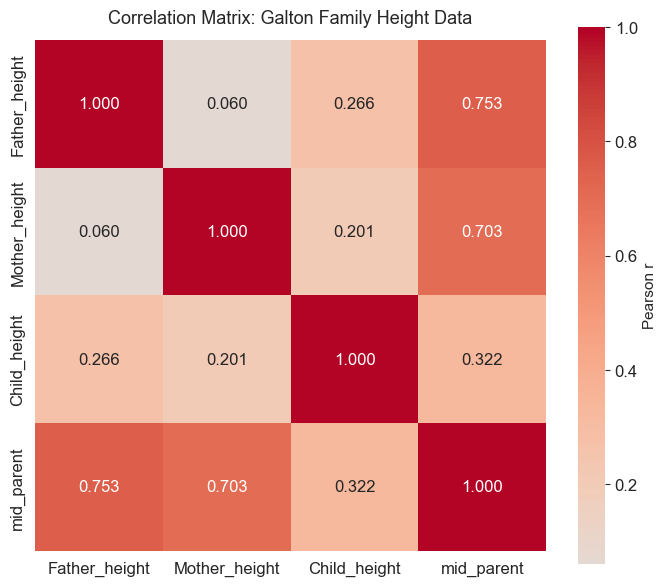

Reading this heatmap: each cell shows the correlation between two variables.
The diagonal is always 1.0 (a variable is perfectly correlated with itself).
Warm colors = positive correlation. Cool colors = negative or zero.


In [10]:
# Correlation heatmap
numeric_cols = df[['Father_height', 'Mother_height', 'Child_height', 'mid_parent']]

plt.figure(figsize=(7, 6))
sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    fmt='.3f',
    cmap='coolwarm',
    center=0,
    square=True,
    cbar_kws={'label': 'Pearson r'}
)
plt.title('Correlation Matrix: Galton Family Height Data', pad=12)
plt.tight_layout()
plt.savefig('figures/correlation_heatmap_nb.png', dpi=150, bbox_inches='tight')
plt.show()

print('Reading this heatmap: each cell shows the correlation between two variables.')
print('The diagonal is always 1.0 (a variable is perfectly correlated with itself).')
print('Warm colors = positive correlation. Cool colors = negative or zero.')

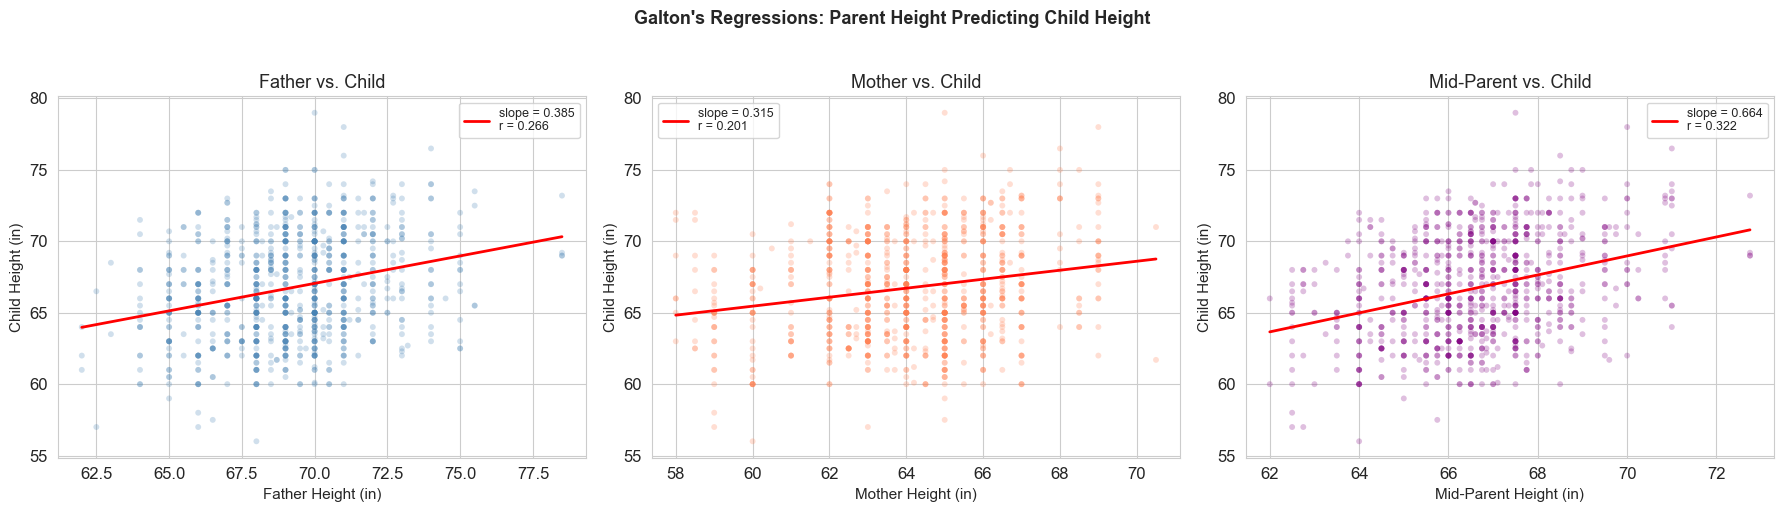

Regression slopes:
  Father  -> Child:      0.3845
  Mother  -> Child:      0.3145
  Mid-Parent -> Child:   0.6645

R-squared (mid-parent model): 0.104
That means mid-parent height explains only 10.4% of the variation in child heights.
The remaining 89.6% comes from factors this model does not capture.


In [11]:
# Three-panel scatter plots with regression lines
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

def scatter_reg(ax, x, y, xlabel, ylabel, title, color='steelblue'):
    ax.scatter(x, y, alpha=0.25, s=18, color=color, edgecolors='none')
    slope, intercept, r_val, p_val, se = stats.linregress(x, y)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, slope * x_line + intercept, color='red', linewidth=2,
            label=f'slope = {slope:.3f}\nr = {r_val:.3f}')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=9)
    return slope, intercept, r_val

scatter_reg(axes[0], df['Father_height'], df['Child_height'],
            'Father Height (in)', 'Child Height (in)', 'Father vs. Child')
scatter_reg(axes[1], df['Mother_height'], df['Child_height'],
            'Mother Height (in)', 'Child Height (in)', 'Mother vs. Child', color='coral')
scatter_reg(axes[2], df['mid_parent'], df['Child_height'],
            'Mid-Parent Height (in)', 'Child Height (in)', 'Mid-Parent vs. Child', color='purple')

plt.suptitle("Galton's Regressions: Parent Height Predicting Child Height",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/scatter_regression_plots_nb.png', dpi=150, bbox_inches='tight')
plt.show()

slope_f = stats_dict['regressions']['child_father_all']['slope']
slope_m = stats_dict['regressions']['child_mother_all']['slope']
slope_mp = stats_dict['regressions']['child_midparent']['slope']
r2_mp = stats_dict['regressions']['child_midparent']['r_squared']

print(f'Regression slopes:')
print(f'  Father  -> Child:      {slope_f}')
print(f'  Mother  -> Child:      {slope_m}')
print(f'  Mid-Parent -> Child:   {slope_mp}')
print()
print(f'R-squared (mid-parent model): {r2_mp}')
print(f'That means mid-parent height explains only {r2_mp*100:.1f}% of the variation in child heights.')
print('The remaining 89.6% comes from factors this model does not capture.')

### The Conceptual Heart: What Is Regression to the Mean?

Look at the slope values you just computed. The slope for mid-parent predicting child height is approximately **0.665**. This is the number that tells the whole story.

A slope of **1.0** would mean: if a parent is 1 inch above average, the child is predicted to be exactly 1 inch above average. No drift. No regression. Traits pass on perfectly.

A slope of **0** would mean: knowing the parent's height tells you absolutely nothing about the child's height. Complete randomness.

A slope of **0.665** means something in between, and it means something specific: **for every inch a parent deviates from the average, the child deviates only 0.665 inches in the same direction.** The child's height gets pulled, by roughly a third, back toward the center.

Let's make this concrete. Using the father-child regression (slope = 0.385):

- Mean father height in this dataset: **69.197"**
- A father who is 2" above average (71.197") is predicted to have a child who is only **0.769" above average**, not 2" above, just 0.769".
- That compression from 2" down to 0.769" is regression to the mean in action.

This is not a flaw in the data. It is a real, documented, mathematically predictable phenomenon. It happens with exam scores, stock returns, athletic performance, and yes, height.

**Here is the implication Galton could not escape:** if every generation drifts back toward the average, then selectively choosing only "tall" parents does not permanently shift the population's height distribution upward. The gains erode. The next generation regresses. Eugenics, as a breeding program, faces a fundamental mathematical headwind, one that Galton's own regression equation quantifies.

He invented the tool that disproved his own argument. He never fully admitted it.

Regression to the Mean , Father Group vs. Average Child Deviation
           Father Group  Avg Child Deviation  Count
Very Short\n(4+" below)            -2.017144     66
    Short\n(2-4" below)            -0.790376    135
   Average\n(within 2")             0.045055    588
     Tall\n(2-4" above)             1.473676    102
 Very Tall\n(4+" above)             1.465696     43



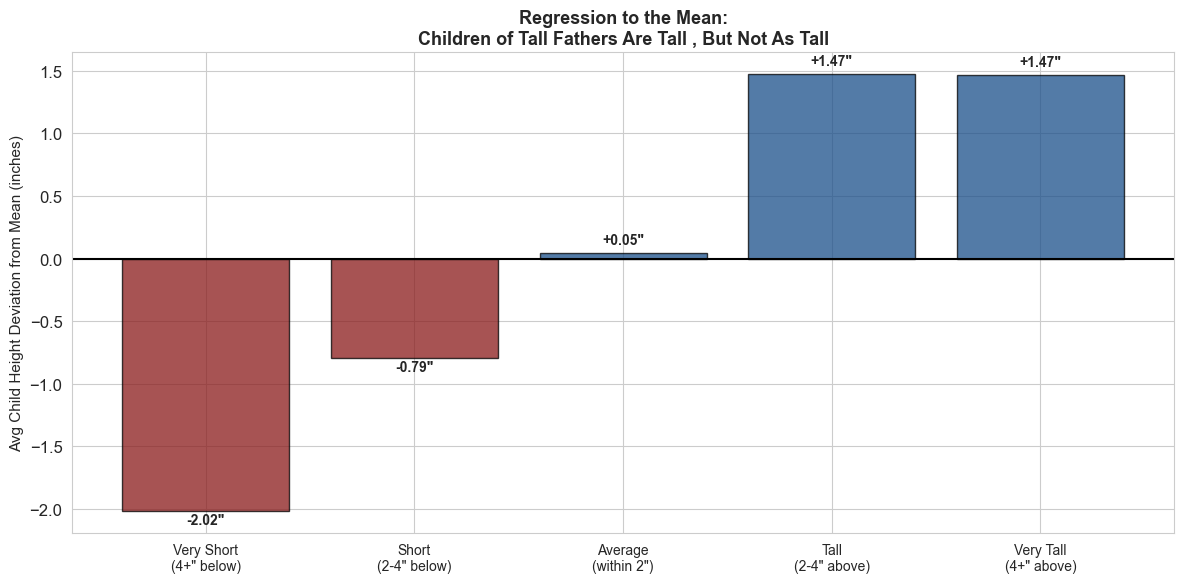

Key number: A father 2" above average has children predicted only 0.769" above average.
The deviation is compressed from 2.000" to 0.769", regression to the mean.


In [12]:
# Regression to the mean demonstration
mean_father = df['Father_height'].mean()
mean_child_all = df['Child_height'].mean()

df['father_deviation'] = df['Father_height'] - mean_father
df['child_deviation']  = df['Child_height'] - mean_child_all

bins       = [-np.inf, -4, -2, 2, 4, np.inf]
bin_labels = ['Very Short\n(4+" below)', 'Short\n(2-4" below)',
              'Average\n(within 2")', 'Tall\n(2-4" above)', 'Very Tall\n(4+" above)']
df['father_group'] = pd.cut(df['father_deviation'], bins=bins, labels=bin_labels)

rtm_data = (
    df.groupby('father_group', observed=False)['child_deviation']
      .agg(['mean', 'count'])
      .reset_index()
)
rtm_data.columns = ['Father Group', 'Avg Child Deviation', 'Count']

print('Regression to the Mean , Father Group vs. Average Child Deviation')
print('=' * 60)
print(rtm_data.to_string(index=False))
print()

# Bar chart
valid_rtm = rtm_data.dropna(subset=['Avg Child Deviation'])
child_devs = valid_rtm['Avg Child Deviation'].values
x_pos = range(len(valid_rtm))

fig, ax = plt.subplots(figsize=(12, 6))
bar_colors = ['#8a1a1a' if d < 0 else '#1a4f8a' for d in child_devs]
bars = ax.bar(x_pos, child_devs, color=bar_colors, alpha=0.75, edgecolor='black')

ax.set_xticks(list(x_pos))
ax.set_xticklabels(valid_rtm['Father Group'].values, fontsize=10)
ax.axhline(0, color='black', linewidth=1.5)
ax.set_ylabel('Avg Child Height Deviation from Mean (inches)')
ax.set_title(
    'Regression to the Mean:\nChildren of Tall Fathers Are Tall , But Not As Tall',
    fontweight='bold'
)

for bar, val in zip(bars, child_devs):
    offset = 0.05 if val >= 0 else -0.13
    ax.text(bar.get_x() + bar.get_width() / 2, val + offset,
            f'{val:+.2f}"', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('figures/regression_to_mean_nb.png', dpi=150, bbox_inches='tight')
plt.show()

compression = stats_dict['rtm_example']['deviation_compression']
print(f'Key number: A father 2" above average has children predicted only {compression}" above average.')
print(f'The deviation is compressed from 2.000" to {compression}", regression to the mean.')

---
## Part 4: The Critique

### Three Problems With Galton's Work

The math in this dataset is real. The patterns are real. But the way the data was collected, framed, and used contains three serious problems that every honest analyst should name directly.

---

**Problem 1: Sampling Bias**

Galton did not draw a random sample of families from the British population. He collected whoever showed up at a paid exhibition in a major city, overwhelmingly middle and upper-class, white, English, with enough money and leisure time to participate. Working-class families, rural families, immigrant families, and anyone who could not afford or access the exhibition are absent.

This is called **convenience sampling** or **selection bias**: the sample was shaped by who was convenient to study, not by what would represent the population. Any statistical conclusions drawn from this sample are most accurately described as conclusions about affluent Victorian Londoners, not about height inheritance in general.

Galton did not flag this limitation. He generalized freely.

---

**Problem 2: Purpose Shapes Design**

Galton was not a neutral, curious scientist who happened to stumble onto a dataset. He was building a scientific case for eugenics, the idea that selective human breeding could improve the race. He chose to study height because it was measurable, visible, and could be used as a proxy for what he believed was heritable "worth."

When the purpose of a study is to justify a predetermined conclusion, every methodological choice, what to measure, who to include, how to analyze the data, gets made in light of that conclusion. This is not always conscious. But it shapes the research in ways that are difficult to separate from the findings afterward.

The tools Galton invented are genuinely powerful and value-neutral in principle. But the questions he used them to answer were never neutral.

---

**Problem 3: The Erasure of Women**

Galton collected heights for both male and female children. But he ran into a problem: male children are on average about 5 inches taller than female children in his dataset. This created two distinct clusters when he plotted the data, and two clusters would have required separate regression equations, complicating the clean universal law he was trying to demonstrate.

His solution: multiply every female height by **1.08**, "transmuting" women into what he called "male equivalents." He did the same to mothers: multiplied their heights by 1.08 before computing mid-parent height. This collapsed the two clusters into one and allowed him to fit a single regression line across all children.

The problem is not merely methodological. By treating male height as the baseline and adjusting women to match it, Galton encoded the assumption that the male body is the normal, universal body, and the female body is a scaled variant that needs correction. This is not a neutral technical choice. It is an ideological one built into the math.

Historian James Hanley documented this technique in a 2012 paper in *The American Statistician*, titled ["'Transmuting' Women into Men: Galton's Family Data on Human Stature"](https://www.tandfonline.com/doi/abs/10.1198/000313004X1558). He showed that the transmutation was not disclosed as a limitation, it was presented as a methodological refinement.

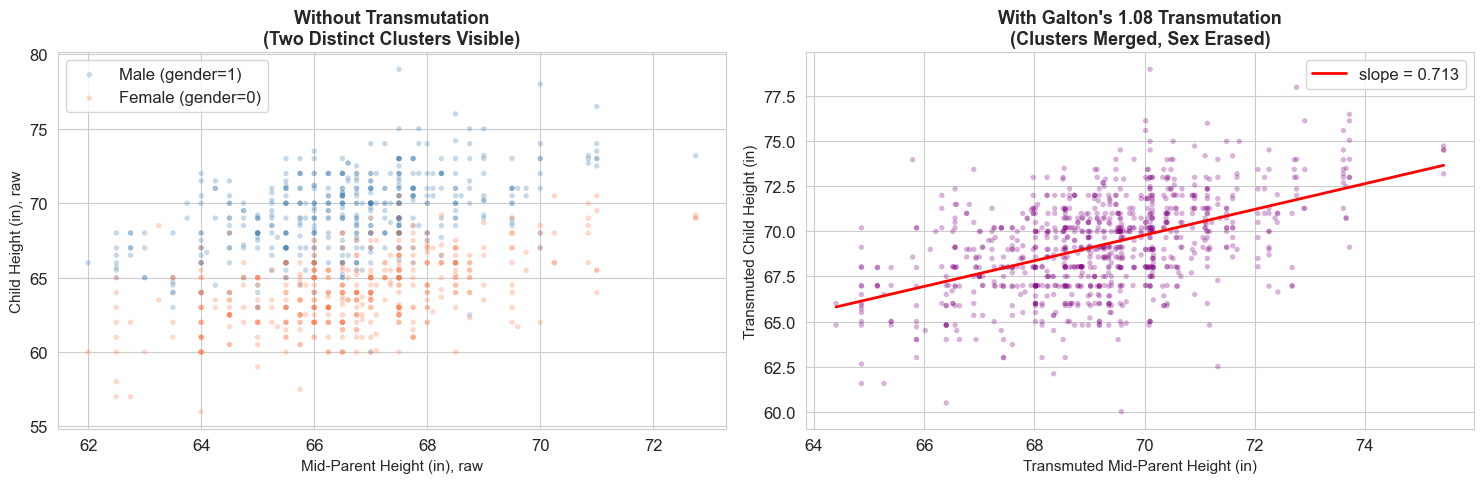

Without transmutation: two distinct clusters. Male and female children are visibly separate.
With transmutation: clusters merged. Sex difference is erased by the 1.08 adjustment.
Galton's resulting slope (transmuted data): 0.713

The 1.08 multiplier is not derived from biology. It was chosen to make the clusters align.
It encodes the assumption that "normal" height means male height.


In [13]:
# Transmutation demonstration
# We create transmuted_height and transmuted_mid_parent as NEW columns, we never overwrite Child_height
df['transmuted_height']     = np.where(df['gender'] == 0,
                                        df['Child_height'] * 1.08,
                                        df['Child_height'])
df['transmuted_mid_parent'] = (df['Father_height'] + df['Mother_height'] * 1.08) / 2

# Note: mid_parent (computed in Part 3) remains raw averages, NOT transmuted
# transmuted_mid_parent is the version with the 1.08 multiplier applied to Mother_height

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Panel 1: raw heights, colored by gender
for g, color, label in [(1, 'steelblue', 'Male (gender=1)'), (0, 'coral', 'Female (gender=0)')]:
    subset = df[df['gender'] == g]
    axes[0].scatter(subset['mid_parent'], subset['Child_height'],
                    alpha=0.3, s=15, color=color, label=label, edgecolors='none')
axes[0].set_xlabel('Mid-Parent Height (in), raw')
axes[0].set_ylabel('Child Height (in), raw')
axes[0].set_title('Without Transmutation\n(Two Distinct Clusters Visible)', fontweight='bold')
axes[0].legend()

# Panel 2: transmuted heights, gender distinction collapsed
axes[1].scatter(df['transmuted_mid_parent'], df['transmuted_height'],
                alpha=0.3, s=15, color='purple', edgecolors='none')
t_slope, t_intercept, t_r, _, _ = stats.linregress(
    df['transmuted_mid_parent'], df['transmuted_height']
)
x_t = np.linspace(df['transmuted_mid_parent'].min(), df['transmuted_mid_parent'].max(), 100)
axes[1].plot(x_t, t_slope * x_t + t_intercept, color='red', linewidth=2,
             label=f'slope = {t_slope:.3f}')
axes[1].set_xlabel('Transmuted Mid-Parent Height (in)')
axes[1].set_ylabel('Transmuted Child Height (in)')
axes[1].set_title('With Galton\'s 1.08 Transmutation\n(Clusters Merged, Sex Erased)', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('figures/transmutation_comparison_nb.png', dpi=150, bbox_inches='tight')
plt.show()

transmutation_slope = stats_dict['transmutation_slope']
print('Without transmutation: two distinct clusters. Male and female children are visibly separate.')
print('With transmutation: clusters merged. Sex difference is erased by the 1.08 adjustment.')
print(f'Galton\'s resulting slope (transmuted data): {transmutation_slope:.3f}')
print()
print('The 1.08 multiplier is not derived from biology. It was chosen to make the clusters align.')
print('It encodes the assumption that "normal" height means male height.')

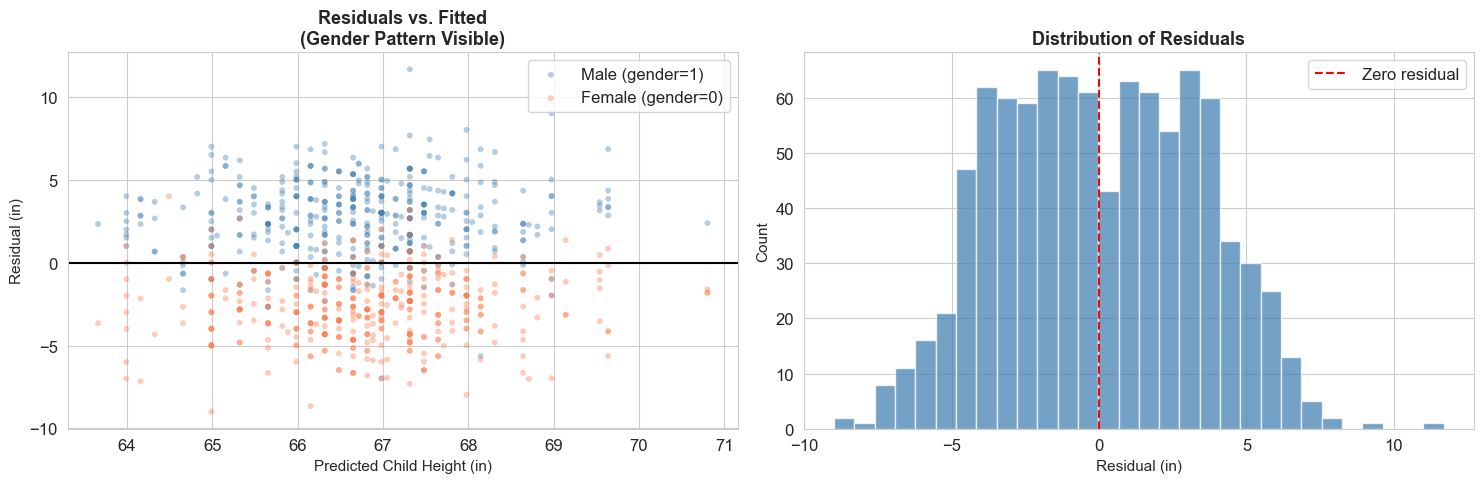

Residual mean: 0.0000" (close to zero , model is unbiased on average)
Residual std:  3.388"

The residual plot (left) shows two horizontal bands, one for males, one for females.
This tells us the single regression model is systematically wrong in opposite directions
for the two groups. The gender pattern in the residuals is the model's confession
that it is missing something important.


In [14]:
# Residual analysis, using the raw mid-parent model (not transmuted)
slope_mp, intercept_mp, _, _, _ = stats.linregress(df['mid_parent'], df['Child_height'])
df['predicted_child'] = slope_mp * df['mid_parent'] + intercept_mp
df['residual']        = df['Child_height'] - df['predicted_child']

# Note: Child_height column is unchanged, we only created new columns 'predicted_child' and 'residual'

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Residuals vs. fitted, colored by gender
for g, color, label in [(1, 'steelblue', 'Male (gender=1)'), (0, 'coral', 'Female (gender=0)')]:
    subset = df[df['gender'] == g]
    axes[0].scatter(subset['predicted_child'], subset['residual'],
                    alpha=0.4, s=18, color=color, label=label, edgecolors='none')
axes[0].axhline(0, color='black', linewidth=1.5)
axes[0].set_xlabel('Predicted Child Height (in)')
axes[0].set_ylabel('Residual (in)')
axes[0].set_title('Residuals vs. Fitted\n(Gender Pattern Visible)', fontweight='bold')
axes[0].legend()

# Distribution of residuals
axes[1].hist(df['residual'], bins=30, color='steelblue', edgecolor='white', alpha=0.75)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero residual')
axes[1].set_xlabel('Residual (in)')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Residuals', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('figures/residual_analysis_nb.png', dpi=150, bbox_inches='tight')
plt.show()

resid_mean = stats_dict['residual_stats']['mean']
resid_std  = stats_dict['residual_stats']['std']
print(f'Residual mean: {resid_mean:.4f}" (close to zero , model is unbiased on average)')
print(f'Residual std:  {resid_std:.3f}"')
print()
print('The residual plot (left) shows two horizontal bands, one for males, one for females.')
print('This tells us the single regression model is systematically wrong in opposite directions')
print('for the two groups. The gender pattern in the residuals is the model\'s confession')
print('that it is missing something important.')

---
### Small Group Discussion
*In groups of 3-4, discuss for 10-15 minutes. Aim for at least one concrete example or piece of evidence for each point.*

1. The correlations we computed range from about 0.20 to 0.43. None are above 0.5. What does that mean for any claim that height is "strongly heritable" in this dataset? Can you have a statistically significant correlation that is still practically very weak?

2. This dataset was collected only from middle and upper-class white London families. If a researcher used these regression equations to make predictions about the heights of children in Nigeria, Mexico, or rural China, what problems would arise? What would need to be different for the model to be valid?

3. Galton's 1.08 multiplier treats male height as the norm and female height as a deviation that needs correction. Who benefits from that framing? Who does it render invisible? Can you think of other places in science or technology where a similar default has been built in?

4. Regression to the mean directly undermines the logic of eugenics. But eugenics remained popular and politically powerful for decades after Galton published his findings. What does that tell you about the relationship between data and ideology? Does correct data automatically change people's minds?

5. Is it possible to separate the statistical tools Galton invented from the purposes he invented them for? Are correlation and regression neutral tools, or do they carry assumptions? Be specific.

---

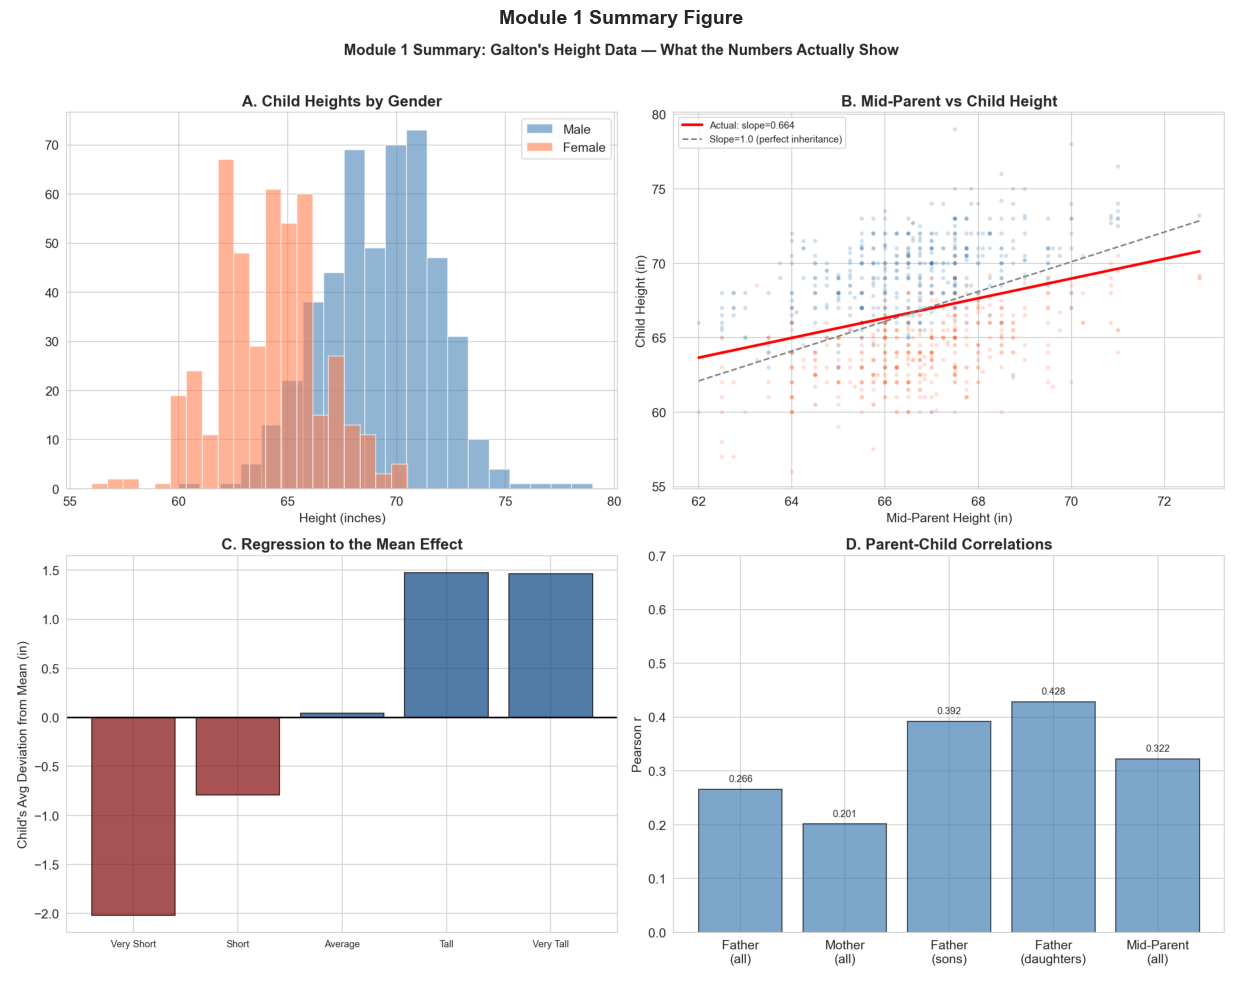

Panel A: Child heights by gender, the bimodal distribution Galton's 1.08 was designed to collapse.
Panel B: Mid-parent vs. child height, slope < 1.0, demonstrating regression to the mean.
Panel C: RTM effect by father's height group, tall fathers have tall children, but less tall.
Panel D: Summary of all parent-child correlations, none above 0.43.


In [15]:
# Summary figure , 4-panel view of the full story
fig, axes = plt.subplots(figsize=(14, 10))
axes.axis('off')

img_summary = mpimg.imread('figures/module1_summary_figure.png')
plt.imshow(img_summary)
plt.axis('off')
plt.title('Module 1 Summary Figure', fontsize=14, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('figures/module1_summary_display.png', dpi=120, bbox_inches='tight')
plt.show()

print('Panel A: Child heights by gender, the bimodal distribution Galton\'s 1.08 was designed to collapse.')
print('Panel B: Mid-parent vs. child height, slope < 1.0, demonstrating regression to the mean.')
print('Panel C: RTM effect by father\'s height group, tall fathers have tall children, but less tall.')
print('Panel D: Summary of all parent-child correlations, none above 0.43.')

---
## Part 5: Synthesis and Reflection

### What We Have Learned

Let's pull the threads together.

Francis Galton set out in the 1880s to build a scientific foundation for eugenics, the controlled breeding of human beings to produce "better" people. He chose height as his primary variable because it was measurable, heritable, and could be used as a proxy for what he believed were superior traits. He collected data from a biased sample, normalized it by erasing the statistical distinctiveness of women, and used the resulting numbers to argue for a eugenic program.

Along the way, he invented correlation, linear regression, and the concept of the standard deviation. These tools work. They are used in virtually every quantitative field today, medicine, economics, machine learning, social science, and yes, data ethics courses.

But here is what the data actually showed: the parent-child correlations in this dataset range from about 0.20 to 0.43. The best regression model, using mid-parent height, explains only **10.4%** of the variation in child heights. And the slope of that regression line is **0.665**, which means that for every inch a parent deviates from the average, the child deviates only about 0.665 inches. Extreme traits pull back toward the center every generation.

That last finding, regression to the mean, is a direct mathematical argument against selective breeding as a reliable mechanism for shifting a population's traits. Galton understood this result. He named it. He just never followed it to its logical conclusion for his own ideology.

This is the lesson of this module, and it applies far beyond Galton:

> **Three questions every responsible data scientist asks:**
> 1. Who collected this data, and why?
> 2. Who was included, and who was left out?
> 3. What assumptions are baked into the methods used to analyze it?

These are not questions that make you distrust math. They are questions that make you do math better.

### Broader Connections

This module is the first of three. Here is where we are headed.

**Module 2: California's Forced Sterilization Program**
Galton's theoretical eugenics did not stay theoretical. In the United States, eugenics became law. California passed a eugenic sterilization statute in 1909, and between 1909 and 1952 the state forcibly sterilized more than **20,000 people**, disproportionately poor people, people with disabilities, immigrants, and people of color, in state hospitals and prisons. We will look at the data trail that documented this program and ask: who counted these people, and to what end?

**Module 3: W.E.B. Du Bois and Data as Witness**
At the same moment Galton was publishing his eugenic statistics, W.E.B. Du Bois was doing something entirely different with data. At the 1900 Paris Exposition, Du Bois presented 63 hand-drawn data visualizations documenting the lives, economic conditions, and social progress of Black Americans in Georgia. He was not using data to rank people. He was using it to bear witness, to make visible the lives that dominant statistics rendered invisible. Module 3 examines what it means to use data as an act of advocacy rather than an act of control.

---
### Individual Reflection
*Choose 2-3 of the following prompts to respond to in writing (one paragraph each). Your teacher will tell you whether to submit or use these as the basis for a class discussion.*

1. Before today, did you know that standard statistical tools like correlation and regression were developed partly to support the eugenics movement? How does knowing that history change, or not change, how you think about using those tools?

2. Galton's own data, when analyzed honestly, provides a mathematical argument *against* eugenics through regression to the mean. But this finding did not stop the eugenics movement, which continued for decades and led to real harm. Why do you think data and logical argument are sometimes insufficient to change ideologically motivated beliefs?

3. This dataset is still included in statistics textbooks and university courses, usually presented without its historical context. Do you think that is a problem? What would need to change, in the dataset itself, in how it is taught, or both, for it to be used responsibly?

4. Think of a dataset you have encountered in another class, in the news, or in everyday life. Using the three critical questions from the synthesis section (Who collected it? Why? Who was left out?), what new questions would you now ask about that dataset?

5. Consider the claim: *"Data is never neutral."* Do you agree, disagree, or partially agree? Use at least one specific example from this module to support your position.

---

### Key Terms Glossary

| Term | Definition |
|---|---|
| **Dataset** | A structured collection of information organized into rows (observations) and columns (variables) |
| **Observation** | One row in a dataset , one unit of study (here, one adult child) |
| **Variable** | One column , a characteristic measured for each observation |
| **Mean** | The arithmetic average of a set of values |
| **Median** | The middle value when data is sorted from lowest to highest |
| **Standard deviation** | A measure of spread , roughly, the average distance of each value from the mean |
| **Distribution** | The overall pattern of how values are spread across a range |
| **Histogram** | A bar chart showing how many observations fall into each value range |
| **Box plot** | A visual summary showing median, quartiles, and outliers |
| **Correlation** | A measure of how strongly two variables move together, ranging from -1 to +1 |
| **Scatter plot** | A graph where each point represents one observation, with two variables on the axes |
| **Pearson r** | The most common correlation statistic; measures linear association |
| **Linear regression** | A method for fitting a straight line that best predicts one variable from another |
| **Slope** | How much the predicted outcome changes for each one-unit increase in the predictor |
| **Intercept** | The predicted value of the outcome when the predictor equals zero |
| **R-squared (R²)** | The proportion of variance in the outcome explained by the model; ranges 0-1 |
| **Residual** | The difference between an actual observed value and the model's predicted value |
| **Regression to the mean** | The tendency for extreme values to be followed by values closer to the average |
| **Sampling bias** | When the process of selecting a sample systematically over- or under-represents some groups |
| **Convenience sample** | A sample drawn from whoever was easy to reach, rather than randomly from the population |
| **Selection bias** | Bias introduced when participants are selected in a way that is not representative |
| **Eugenics** | The discredited ideology that human populations can and should be improved through selective reproduction |

### What's Next: Module 2 Preview

Galton published his theories. Other people built institutions around them.

In Module 2, we move from Victorian England to twentieth-century California. Between 1909 and 1952, California operated the most active forced sterilization program in the United States , and it kept meticulous records. We will work with the data from that program: who was sterilized, where, diagnosed with what, and by whom. The numbers are not abstract. They represent real people whose autonomy was taken from them in the name of science. Our job will be to read those numbers carefully , to ask what the data reveals, what it conceals, and what it means to analyze a dataset built from an act of state violence. Module 2 also introduces statistical concepts including conditional probability, base rates, and the difference between a diagnosis and a measurement.

The question we will bring from this module into the next: *when data is collected to justify control over people's bodies, what responsibility do analysts have when they use that data decades later?*

---

### Author

- [Parshv Patel](https://www.linkedin.com/in/parshv-patel-65a90326b/)